# ANNNI model with time evolution
Taken and adapted from <https://pennylane.ai/qml/demos/tutorial_quantum_phase_transitions>

## Create the hamiltonian

In [37]:
import pennylane as qml
import random

from pennylane import numpy as np

N = 3
k = 1
h = 1
wires = range(N)

dev = qml.device("lightning.qubit", wires=N)

def get_H(num_spins, k, h):
    """Construction function the ANNNI Hamiltonian (J=1)"""

    # Interaction between spins (neighbouring):
    H = -1 * (qml.PauliX(0) @ qml.PauliX(1))
    for i in range(1, num_spins - 1):
        H = H  - (qml.PauliX(i) @ qml.PauliX(i + 1))

    # Interaction between spins (next-neighbouring):
    for i in range(0, num_spins - 2):
        H = H + k * (qml.PauliX(i) @ qml.PauliX(i + 2))

    # Interaction of the spins with the magnetic field
    for i in range(0, num_spins):
        H = H - h * qml.PauliZ(i)

    return H

H = get_H(N,k,h) 

print(f"H = {H}")  


H = -1 * (X(0) @ X(1)) + -1 * (X(1) @ X(2)) + 1 * (X(0) @ X(2)) + -1 * Z(0) + -1 * Z(1) + -1 * Z(2)


## Use VQE to find the Ground State

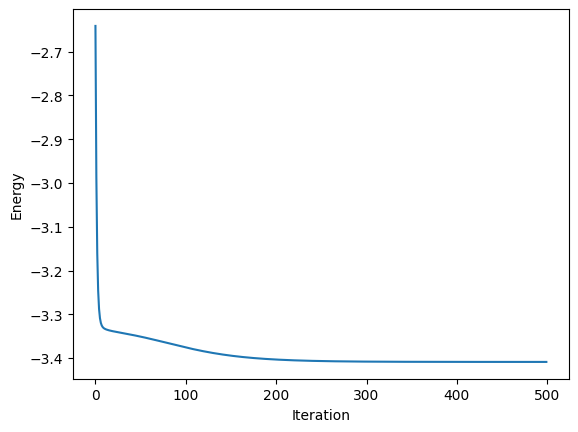

-3.4086863763317097


In [6]:
# create an ansatz using the hardware efficiency ansatz (HEA)
def create_ansatz(params, N):
    # STEP 1: perform single-qubit rotations on all the qubits
    for i in range(N):
        qml.RZ(phi=params[i], wires=i)
        qml.RX(phi=params[N + i], wires=i)
        qml.RZ(phi=params[2 * N + i], wires=i)

    # STEP 2: perform a CNOT gate on each pair of neighbouring qubits
    for i in range(N - 1):
        qml.CNOT(wires=[i, i + 1])

    # STEP 3: perform single-qubit rotations on all the qubits
    for i in range(N):
        qml.RZ(phi=params[3 * N + i], wires=i)
        qml.RX(phi=params[4 * N + i], wires=i)
        qml.RZ(phi=params[5 * N + i], wires=i)



def find_ground_state(N,k,h, max_iters = 200, tolerance = 1e-04, seed=None):
    # This function applies the VQE to find the ground state of a given hamiltonian
    # max_iters = 200, tolerance = 1e-04

    H_ = get_H(N,k,h)
    
    import random
    if seed is None:
        random.seed()
    else:
        random.seed(a=seed)
    
    # params is an array that stores the parameter values of the statevector that we use in VQE.
    # Generate some initial random angle values.
    params = np.array([2 * np.pi * random.uniform(0, 1)] * (6 * N), requires_grad=True)


    @qml.qnode(dev)
    def quantum_circuit(params):
        # Create a quantum state using params
        create_ansatz(params, N)
        return qml.expval(H_)
    


    # create an optimizer
    opt = qml.GradientDescentOptimizer(stepsize=0.1)
    
    # energy is a list that stores all the estimates for the ground-state energy
    energy = []
    
    # execute the VQE optimization loop
    for i in range(max_iters):
        params, prev_energy = opt.step_and_cost(quantum_circuit, params)
        energy.append(prev_energy)
    
        if i > 1:
            if np.abs(energy[-2] - energy[-1]) < tolerance:
                break

    return params, energy

# graph the energy as a function of the number of iterations
import matplotlib.pyplot as plt

params, energy = find_ground_state(N, k, h, max_iters=500, tolerance = 1e-07)
plt.plot(list(range(len(energy))), energy)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()

print(energy[-1])


## Classical time evolution

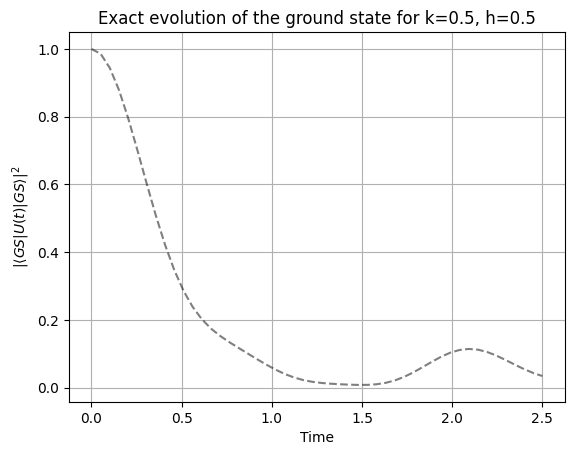

In [75]:
def U_t(H, t):
    from scipy.linalg import expm
    H_mat = qml.matrix(H)
    return expm(-1.0j * H_mat * t)

N = 5
k = 0.5
h = 0.5

H = get_H(N,k,h)

wires = range(N)
dev = qml.device("lightning.qubit", wires=N)


params, _ = find_ground_state(N, k, h, max_iters=500, tolerance=1e-07, seed=10)

@qml.qnode(dev)
def get_initial_state(params,N):
    create_ansatz(params, N)
    return qml.state()

initial_state = get_initial_state(params,N)

T_start = 0
deltaT = 0.05
num_time_steps = 50
times = np.linspace(T_start, T_start+deltaT*num_time_steps, num_time_steps)



params = np.array([2 * np.pi * random.uniform(0, 1)] * (6 * N), requires_grad=True)
initial_state = get_initial_state(params,N)

def exact_evol(H,T,params,N):
    initial_state = get_initial_state(params,N)
    evolved_state = U_t(H, t) @ initial_state
    return evolved_state
    
exact_probs = []

# for t in times:
# # evolved_state = U_t(H, t) @ initial_state
# evolved_state = exact_evol(H,t,params)
# overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
# exact_probs.append(overlap)

prob_list_exact = []
for t in times:
    evolved_state = exact_evol(H, t, params,N)
    overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
    prob_list_exact.append(overlap)

plt.plot(times, prob_list_exact, linestyle="--", color="black", alpha=0.5)
plt.title(f"Exact evolution of the ground state for k={k:.2}, h={h:.2}")
plt.xlabel("Time")
plt.ylabel(r"$|\langle GS|U(t)|GS\rangle|^2$")
plt.grid()
plt.show()


We notice that the VQE did not find a good ground state, so the probability quickly diverges from 1.  
Let's try a new and better VQE created by us (codes [here](https://github.com/alexsockz/ANNNI-model-quantum-computing/blob/main/src/VQE.py))

## Time evolution circuit with Trotterization

In [76]:
N = 5
k = 0.5
h = 0.5

H = get_H(N,k,h)

wires = range(N)
dev = qml.device("lightning.qubit", wires=N)

# params, _ = find_ground_state(N, k, h, max_iters=500, tolerance=1e-07, seed=10)
params = np.array([2 * np.pi * random.uniform(0, 1)] * (6 * N), requires_grad=True)


import math

# create the circuit that evolves the system in time
@qml.qnode(dev)
def time_evolution_circuit(H, T, params):
    create_ansatz(params,N)
    #Evolve the system via a sequence of short approximate Trotter time steps
    #https://docs.pennylane.ai/en/stable/code/api/pennylane.TrotterProduct.html
    qml.TrotterProduct(H, time=T, n=math.ceil(T / 0.1)+1, order=2)

    # return the final probabilities
    return qml.state()
    # return qml.probs(wires=range(N))

Instead of using the function `qml.TrotterProduct` we could have used multiple steps of following:

In [77]:
def trotter_step(dt,k,h):
    for i in range(0, N -1):
        qml.IsingXX(-2*dt,[i,i+1])
    for i in range(0, N - 2):
        qml.IsingXX(2*dt*k,[i,i+2])
    for i in range(0, N):
        qml.RZ(-2*dt*h,i)

In [78]:
@qml.qnode(dev)
def trotter_evolution_circuit(k,h, T, params):
    create_ansatz(params,N)
    n=math.ceil(T / 0.1)+1
    dt = T/n
    for i in range(n):
        trotter_step(dt,k,h)
    return qml.state()

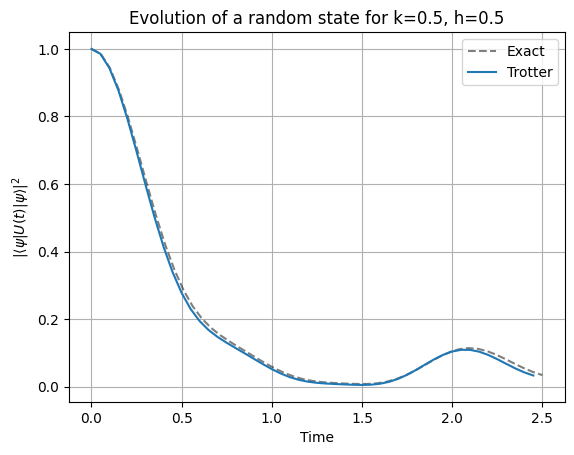

In [85]:
#prob_list_exact = []
prob_list = []
prob_list_1 = []

# random state
# params = np.array([2 * np.pi * random.uniform(0, 1)] * (6 * N), requires_grad=True)
initial_state = get_initial_state(params,N)
# 
# time step size for time evolution
T_start = 0
deltaT = 0.05
num_time_steps = 50

# for i in range(num_time_steps):
#     evolved_state = exact_evol(H, T_start + i * deltaT, params,N)
#     overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
#     prob_list_exact.append(overlap)

    
    #overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
    #exact_probs.append(overlap)

for i in range(num_time_steps):
    evolved_state = time_evolution_circuit(H, T_start + i * deltaT, params)
    overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
    prob_list.append(overlap)

# for i in range(num_time_steps):
#     evolved_state = trotter_evolution(k,h, T_start + i * deltaT, params)
#     overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
#     prob_list_1.append(overlap)

# plt.plot(np.linspace(T_start, T_start + deltaT * (num_time_steps-1), num_time_steps), prob_list_exact,linestyle="--", color="black", alpha=0.5)
plt.plot(times, prob_list_exact, linestyle="--", color="black", alpha=0.5)
plt.plot(np.linspace(T_start, T_start + deltaT * (num_time_steps-1), num_time_steps), prob_list)
# plt.plot(np.linspace(T_start, T_start + deltaT * (num_time_steps-1), num_time_steps), prob_list_1)
plt.title(f"Evolution of a random state for k={k:.2}, h={h:.2}")
plt.xlabel("Time")
plt.ylabel(r"$|\langle \psi|U(t)|\psi\rangle|^2$")
plt.legend(["Exact","Trotter","Trotter step"])
plt.grid()
plt.show()


## Magnetization time evolution

### Define magnetization operator

In [165]:
# A function that returns the magnetization operator of N qubits.
def magnetization_op(N):
    total_op = qml.PauliZ(0)

    if N > 1:
        for i in range(1, N):
            total_op = total_op + qml.PauliX(i)

    return total_op / N

# #Return the value of the magnetization operator for the ground state
# @qml.qnode(dev)
# def calculate_magnetization_GS(H,N):
#     params, _ = find_ground_state(N, k, h, max_iters=500, tolerance = 1e-07)
#     create_ansatz(params, N)
#     return qml.expval(magnetization_op(N))


def magnetization_x(N):
    total_op = qml.PauliX(0)
    if N > 1:
        for i in range(1, N):
            total_op = total_op + qml.PauliX(i)
    return total_op / N

def magnetization_z(N):
    total_op = qml.PauliZ(0)
    if N > 1:
        for i in range(1, N):
            total_op = total_op + qml.PauliZ(i)
    return total_op / N

def staggered_magnetization_x(N):
    total_op = qml.PauliX(0)
    if N > 1:
        for i in range(1, N):
            total_op = total_op + (-1)**i * qml.PauliX(i)
    return total_op / N


In [166]:
# Define a function to calculate magnetization at time t
# def calculate_expval_at_time(H, t, N, ground_state_params, operator):
def calculate_expval_at_time(H, t, N, ground_state, operator):
    """Calculate magnetization after time evolution"""
    
    # Create a device for the circuit
    dev = qml.device("lightning.qubit", wires=range(N))
    
    @qml.qnode(dev)
    def magnetization_circuit():
        # Prepare the ground state
        # create_ansatz(ground_state_params, N)
        qml.StatePrep(ground_state, wires=range(N))
        # Apply time evolution
        qml.TrotterProduct(H, time=t, n=math.ceil(t / 0.1)+1, order=2)
        # Return magnetization expectation value
        # return qml.expval(operator(N))
        return qml.expval(magnetization_op(N))

    return magnetization_circuit()

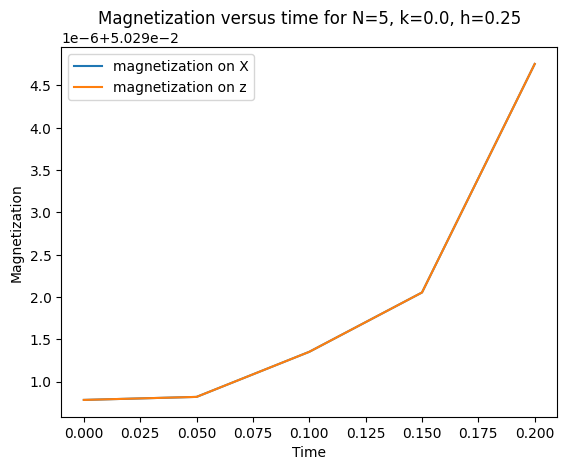

In [169]:
# Get the ground state
k = 0.
h = 0.25

H_matrix = qml.matrix(get_H(N, k, h))
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]

# H_matrix = qml.matrix(get_H(N, k, h))
# _, psi0 = np.linalg.eigh(H_matrix)
# ground_state_params = np.array(psi0[:, 0], dtype=np.complex64)
# ground_state_params = psi0[:, 0]

# Calculate magnetization over time
deltaT = 0.05
num_time_steps = 5
H = get_H(N,k,h)

magnetization_list = []
for i in range(num_time_steps):
    mag = calculate_expval_at_time(H, i * deltaT, N, ground_state_params,magnetization_x)
    magnetization_list.append(mag)
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), magnetization_list, label='magnetization on X')

magnetization_list = []
for i in range(num_time_steps):
    mag = calculate_expval_at_time(H, i * deltaT, N, ground_state_params,magnetization_z)
    magnetization_list.append(mag)
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), magnetization_list, label='magnetization on z')

# magnetization_list = []
# for i in range(num_time_steps):
#     mag = calculate_expval_at_time(H, i * deltaT, N, ground_state_params,staggered_magnetization_x)
#     magnetization_list.append(mag)
# plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), magnetization_list, label='staggered magnetization on X')


plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title(f"Magnetization versus time for N={N}, k={k}, h={h}")
plt.legend()
plt.show()

## New trial magnetization

In [184]:
def ferro_order_parameter(N):
    """
    Somma di tutti i correlatori X_i X_j, normalizzata.
    Equivale a <m_X^2> = <(sum_i X_i)^2> / N^2
    Rimane finito in fase ferro, cade a 0 in fase para/antifase.
    """
    # Costruisce sum_{i,j} X_i @ X_j
    op = qml.PauliX(0) @ qml.PauliX(0)  # inizializzazione (=identità su qubit 0)
    op = qml.PauliX(0) @ qml.PauliX(0)
    
    # Modo più diretto: costruire (sum_i X_i)^2 esplicitamente
    # PennyLane supporta prodotti di operatori Hamiltoniani
    M_X = qml.PauliX(0)
    for i in range(1, N):
        M_X = M_X + qml.PauliX(i)
    
    return (M_X @ M_X) * (1 / N**2)

def long_range_correlator(N):
    """
    Correlatore X_0 X_{N-1}: indicatore diretto di ordine ferro a lungo raggio.
    """
    return qml.PauliX(0) @ qml.PauliX(N - 1)

def magnetization_z(N):
    """
    Magnetizzazione lungo Z: l'unico parametro d'ordine diretto (non rotto da simmetria).
    Tende a 1 in fase para, a 0 in fase ferro/antifase.
    """
    total_op = qml.PauliZ(0)
    for i in range(1, N):
        total_op = total_op + qml.PauliZ(i)
    return total_op * (1 / N)

def staggered_magnetization_x_antiphase(N):
    """
    Staggered m_X con pattern ++-- (periodo 4), corretto per la fase antifase ANNNI.
    Usa (-1)*(i//2), NON (-1)*i che darebbe l'antiferromagnete.
    """
    signs = [(-1) ** (i // 2) for i in range(N)]
    total_op = signs[0] * qml.PauliX(0)
    for i in range(1, N):
        total_op = total_op + signs[i] * qml.PauliX(i)
    return total_op * (1 / N)

def staggered_order_parameter_antiphase(N):
    """
    Versione quadratica: <m_stagg^2>, invariante sotto la simmetria Z2.
    Questo è il vero parametro d'ordine finito-size per la fase antifase.
    """
    signs = [(-1) ** (i // 2) for i in range(N)]
    M_stagg = signs[0] * qml.PauliX(0)
    for i in range(1, N):
        M_stagg = M_stagg + signs[i] * qml.PauliX(i)
    return (M_stagg @ M_stagg) * (1 / N**2)

In [207]:
def calculate_order_parameters(H, t, N, ground_state):
    """
    Calcola tutti i parametri d'ordine al tempo t.
    Restituisce un dizionario con i valori.
    """
    dev = qml.device("lightning.qubit", wires=range(N))

    # --- Costruzione operatori ---
    # m_Z (diretto)
    op_mz = magnetization_z(N)

    # <m_X^2> (ferromagnetico)
    M_X = qml.PauliX(0)
    for i in range(1, N): M_X = M_X + qml.PauliX(i)
    op_mx2 = (M_X @ M_X) * (1 / N**2)

    # correlatore a lungo raggio X_0 X_{N-1}
    op_corr = qml.PauliX(0) @ qml.PauliX(N - 1)

    # <m_stagg^2> (antifase, pattern ++--)
    signs = [(-1) ** (i // 2) for i in range(N)]
    M_st = signs[0] * qml.PauliX(0)
    for i in range(1, N): M_st = M_st + signs[i] * qml.PauliX(i)
    op_mst2 = (M_st @ M_st) * (1 / N**2)

    n_steps = max(math.ceil(t / 0.1) + 1, 1)

    @qml.qnode(dev)
    def circuit(op):
        qml.StatePrep(ground_state, wires=range(N))
        if t > 0:
            qml.TrotterProduct(H, time=t, n=n_steps, order=2)
        return qml.expval(op)

    return {
        "m_Z":        float(circuit(op_mz)),
        "m_X^2":      float(circuit(op_mx2)),
        # "corr_X0XN":  float(circuit(op_corr)),
        "m_stagg^2":  float(circuit(op_mst2)),
    }


## ## Schema riassuntivo delle fasi
## ```
## Fase           | m_Z    | <m_X²>  | <X₀X_{N-1}> | <m_stagg²>
## ---------------|--------|---------|-------------|------------
## Ferromagnetica | ≈ 0    | grande  | grande      | piccolo
## Paramagnetica  | ≈ 1    | piccolo | ≈ 0         | piccolo
## Antifase       | ≈ 0    | piccolo | oscillante  | grande

In [192]:
N = 5
k = 1
h = 0.2
t=0

H = get_H(N,k,h)
H_matrix = qml.matrix(H)
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]

calculate_order_parameters(H,t,N,ground_state_params)

{'m_Z': 0.45742572927277264,
 'm_X^2': 0.04602237234856791,
 'corr_X0XN': -0.3048171766312582,
 'm_stagg^2': 0.3063541552296362}

In [193]:
def kt_transition(k):
    """Kosterlitz-Thouless transition line"""
    return 1.05 * np.sqrt((k - 0.5) * (k - 0.1))

def ising_transition(k):
    """Ising transition line"""
    return np.where(k == 0, 1, (1 - k) * (1 - np.sqrt((1 - 3 * k + 4 * k**2) / (1 - k))) / np.maximum(k, 1e-9))

def bkt_transition(k):
    """Floating Phase transition line"""
    return 1.05 * (k - 0.5)

def get_phase(k, h):
    """Get the phase from the DMRG transition lines"""
    # If under the Ising Transition Line (Left side)
    if k < .5 and h < ising_transition(k):
        return 0 # Ferromagnetic
    # If under the Kosterlitz-Thouless Transition Line (Right side)

    elif k > .5 and h < kt_transition(k):
        return 1 # Antiphase
    return 2 # else it is Paramagnetic

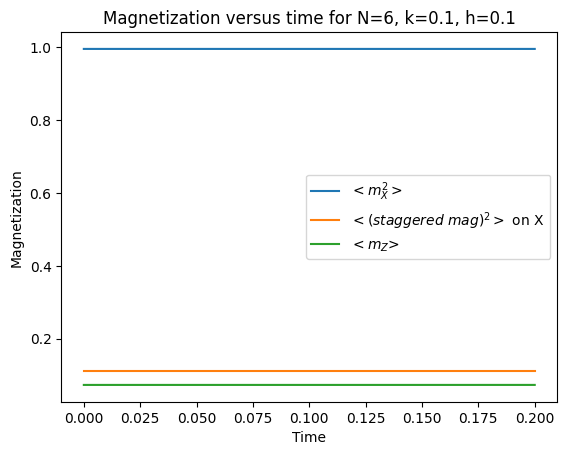

In [225]:
N = 6
k = 0.1
h = 0.1

H = get_H(N, k, h)
H_matrix = qml.matrix(H)
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]


# Calculate magnetization over time
deltaT = 0.05
num_time_steps = 5

mag_z_list = []
mag_x2_list = []
mag_stag_list = []
for i in range(num_time_steps):
    mags = calculate_order_parameters(H, i * deltaT, N, ground_state_params)
    mag_z_list.append(mags["m_Z"])
    mag_x2_list.append(mags["m_X^2"])
    mag_stag_list.append(mags["m_stagg^2"])
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_x2_list, label=f'$<m_X^2>$')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_stag_list, label=f'$<(staggered$ $mag)^2>$ on X')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_z_list, label=f'$<m_Z$>')


plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title(f"Magnetization versus time for N={N}, k={k}, h={h:.2}")
plt.legend()
plt.show()

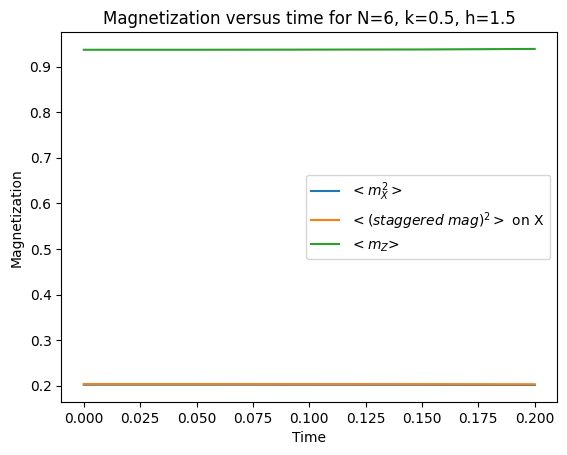

In [226]:
N = 6
k = 0.5
h = 1.5

H = get_H(N, k, h)
H_matrix = qml.matrix(H)
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]


# Calculate magnetization over time
deltaT = 0.05
num_time_steps = 5

mag_z_list = []
mag_x2_list = []
mag_stag_list = []
for i in range(num_time_steps):
    mags = calculate_order_parameters(H, i * deltaT, N, ground_state_params)
    mag_z_list.append(mags["m_Z"])
    mag_x2_list.append(mags["m_X^2"])
    mag_stag_list.append(mags["m_stagg^2"])
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_x2_list, label=f'$<m_X^2>$')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_stag_list, label=f'$<(staggered$ $mag)^2>$ on X')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_z_list, label=f'$<m_Z$>')


plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title(f"Magnetization versus time for N={N}, k={k}, h={h:.2}")
plt.legend()
plt.show()

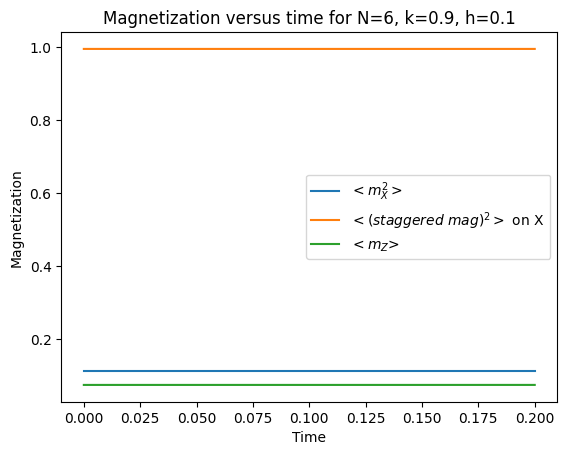

In [227]:
N = 6
k = 0.9
h = 0.1

H = get_H(N, k, h)
H_matrix = qml.matrix(H)
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]


# Calculate magnetization over time
deltaT = 0.05
num_time_steps = 5

mag_z_list = []
mag_x2_list = []
mag_stag_list = []
for i in range(num_time_steps):
    mags = calculate_order_parameters(H, i * deltaT, N, ground_state_params)
    mag_z_list.append(mags["m_Z"])
    mag_x2_list.append(mags["m_X^2"])
    mag_stag_list.append(mags["m_stagg^2"])
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_x2_list, label=f'$<m_X^2>$')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_stag_list, label=f'$<(staggered$ $mag)^2>$ on X')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_z_list, label=f'$<m_Z$>')


plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title(f"Magnetization versus time for N={N}, k={k}, h={h:.2}")
plt.legend()
plt.show()

In [ ]:
N = 6
k = 0.2
h = ising_transition(k)

H = get_H(N, k, h)

k += 0.05
h += 0.05
H_matrix = qml.matrix(get_H(N, k, h))
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]


# Calculate magnetization over time
# deltaT = 0.05
# num_time_steps = 50
deltaT = 0.2
num_time_steps = 25

mag_z_list = []
mag_x2_list = []
mag_stag_list = []
for i in range(num_time_steps):
    mags = calculate_order_parameters(H, i * deltaT, N, ground_state_params)
    mag_z_list.append(mags["m_Z"])
    mag_x2_list.append(mags["m_X^2"])
    mag_stag_list.append(mags["m_stagg^2"])
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_x2_list, label=f'$<m_X^2>$')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_stag_list, label=f'$<(staggered$ $mag)^2>$ on X')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_z_list, label=f'$<m_Z$>')


plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title(f"Magnetization versus time for N={N}, k={k}, h={h:.2}")
plt.legend()
plt.show()

In [ ]:
N = 6
k = 0.8
h = kt_transition(k)

H = get_H(N, k, h)

k -= 0.05
h += 0.05
H_matrix = qml.matrix(get_H(N, k, h))
eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state_params = eigvecs[:, np.argmin(eigvals)]


# Calculate magnetization over time
deltaT = 0.2
num_time_steps = 25

mag_z_list = []
mag_x2_list = []
mag_stag_list = []
for i in range(num_time_steps):
    mags = calculate_order_parameters(H, i * deltaT, N, ground_state_params)
    mag_z_list.append(mags["m_Z"])
    mag_x2_list.append(mags["m_X^2"])
    mag_stag_list.append(mags["m_stagg^2"])
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_x2_list, label=f'$<m_X^2>$')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_stag_list, label=f'$<(staggered$ $mag)^2>$ on X')
plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), mag_z_list, label=f'$<m_Z$>')


plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.title(f"Magnetization versus time for N={N}, k={k}, h={h:.2}")
plt.legend()
plt.show()

## Dynamical phase transition

To see if a dynamical phase transition happens, let’s consider an observable called the rate function $\gamma$. It depends on the overlap between the quantum state that we start with and the final state at some time $t$. More specifically,
$$\gamma = -\frac{1}{N} \log_{e} (|G|^{2}),$$
where $G = \langle \psi_{i} | \psi_{f}\rangle$, $| \psi_{i}\rangle$ and $| \psi_{f}\rangle$ and are the initial and final states, respectively. As the system evolves, we’ll keep calculating $\gamma$. If it changes discontinuously, then a dynamical phase transition has happened.

Time progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:45<00:00,  1.65s/it]


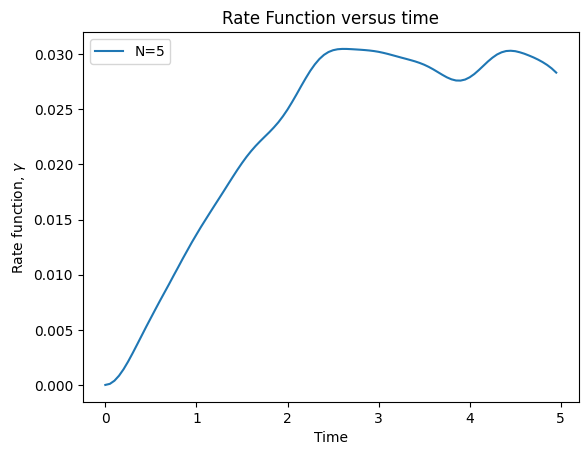

In [8]:
import tqdm

def rate_function(H, T, N, k, h):
    """Calculate the rate function gamma = -1/N * log(|<ψ_i|ψ_f>|^2)"""
    
    dev = qml.device("lightning.qubit", wires=range(N))

    # Create the initial ground state and final state separately
    @qml.qnode(dev)
    def overlap_circuit():
        create_ansatz(ground_state_params, N)
        qml.TrotterProduct(H, time=T, n=math.ceil(T / 0.1)+1, order=2)
        return qml.state()
        
    @qml.qnode(dev)
    def initial_state_circuit():
        create_ansatz(params, N)
        return qml.state()

    final_state = overlap_circuit()
    initial_state = initial_state_circuit()
    
    # Calculate overlap
    overlap = np.abs(np.dot(np.conj(initial_state), final_state))**2
    
    return -1/N * np.log(overlap + 1e-15)  # Add small epsilon to avoid log(0)

# Calculate rate function over time
rate_function_list = []
deltaT = 0.05
num_time_steps = 50

pbar= tqdm.tqdm(total=num_time_steps,desc="Time progress")
for i in range(num_time_steps):
    pbar.update(1)
    rate = rate_function(H, i * deltaT, N, 0, 1)
    rate_function_list.append(rate)
pbar.close()

plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), rate_function_list)
plt.xlabel("Time")
plt.ylabel(r"Rate function, $\gamma$")
plt.title("Rate Function versus time")
plt.legend(["N=" + str(N)])
plt.show()

In [9]:
def kt_transition(k):
    """Kosterlitz-Thouless transition line"""
    return 1.05 * np.sqrt((k - 0.5) * (k - 0.1))

def ising_transition(k):
    """Ising transition line"""
    return np.where(k == 0, 1, (1 - k) * (1 - np.sqrt((1 - 3 * k + 4 * k**2) / (1 - k))) / np.maximum(k, 1e-9))

def bkt_transition(k):
    """Floating Phase transition line"""
    return 1.05 * (k - 0.5)

def get_phase(k, h):
    """Get the phase from the DMRG transition lines"""
    # If under the Ising Transition Line (Left side)
    if k < .5 and h < ising_transition(k):
        return 0 # Ferromagnetic
    # If under the Kosterlitz-Thouless Transition Line (Right side)

    elif k > .5 and h < kt_transition(k):
        return 1 # Antiphase
    return 2 # else it is Paramagnetic


Time progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [06:09<00:00,  2.46s/it]


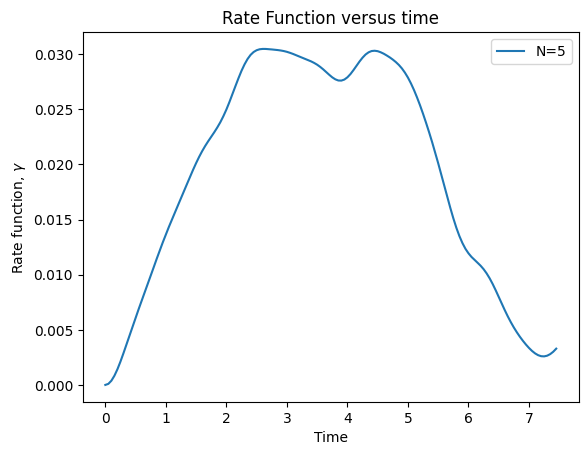

In [10]:

k_transition = 0.2
h_transition = ising_transition(k_transition)  

# Calculate rate function over time
rate_function_list = []
deltaT = 0.05
num_time_steps = 150

pbar= tqdm.tqdm(total=num_time_steps,desc="Time progress")
for i in range(num_time_steps):
    pbar.update(1)
    rate = rate_function(H, i * deltaT, N, k_transition, h_transition)
    rate_function_list.append(rate)
pbar.close()

plt.plot(np.linspace(0, deltaT * (num_time_steps-1), num_time_steps), rate_function_list)
plt.xlabel("Time")
plt.ylabel(r"Rate function, $\gamma$")
plt.title("Rate Function versus time")
plt.legend(["N=" + str(N)])
plt.show()